In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# rest of the code is generalised
ticker = "PLY.AX"

In [ ]:
# data covers all available for PLY
df = yf.download(ticker, start="2020-01-01", end="2026-03-26")

[*********************100%***********************]  1 of 1 completed


In [ ]:
# for plotting volatility, measured as the standard deviation of log returns over the window
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
window = 10 # chose window of 10 as it's two weeks 
df["vol"] = df["log_return"].rolling(window).std() *np.sqrt(252)

# for ewma volatility
alpha_value = 0.1 # lambda = 1- alpha so lambda = 0.9 is equivalent 
df["ewma_vol"] = df["log_return"].ewm(alpha=alpha_value, adjust=False).std() *np.sqrt(252)


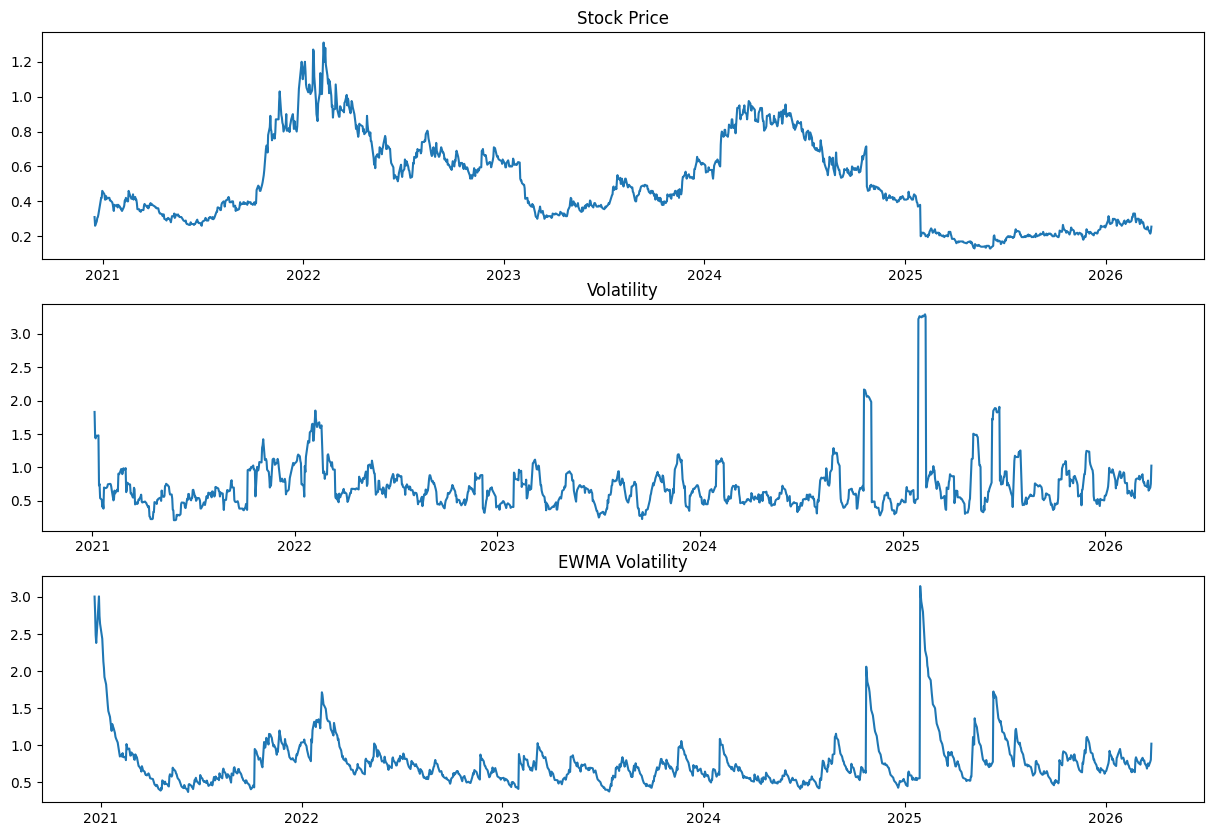

In [ ]:
# the three required plots
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(df.index, df["Close"])
plt.title("Stock Price")

plt.subplot(3, 1, 2)
plt.plot(df.index, df["vol"])
plt.title("Volatility")

plt.subplot(3, 1, 3)
plt.plot(df.index, df["ewma_vol"])
plt.title("EWMA Volatility")

plt.show()

In [ ]:
# Step 1 of the doc, defining factor exposures

# liquidity: measured by dollar volume 
df["dollar_volume"] = df["Close"] * df["Volume"]

# liquidity: measured by turnover ratio
# shares_outstanding = yf.Ticker(ticker).info.get("sharesoutstanding")
# df["turnover_rate"] = df["Volume"] / shares_outstanding
# couldn't do this as the .info.get("sharesoutstanding") keeps on showing NoneType for some reason

# we will proceed with dollar volume as liquidity measure

# we standardise dollar volume over whole timeframe and extract a value to represent factor exposure 
liquidity = (df["dollar_volume"] - df["dollar_volume"].mean()) / df["dollar_volume"].std()
liquidity_factor_exposure = liquidity.dropna().iloc[-1]

# final answer for factor exposure
print(liquidity_factor_exposure)


-0.4135509749342441


Text(0.5, 1.0, 'Liquidity')

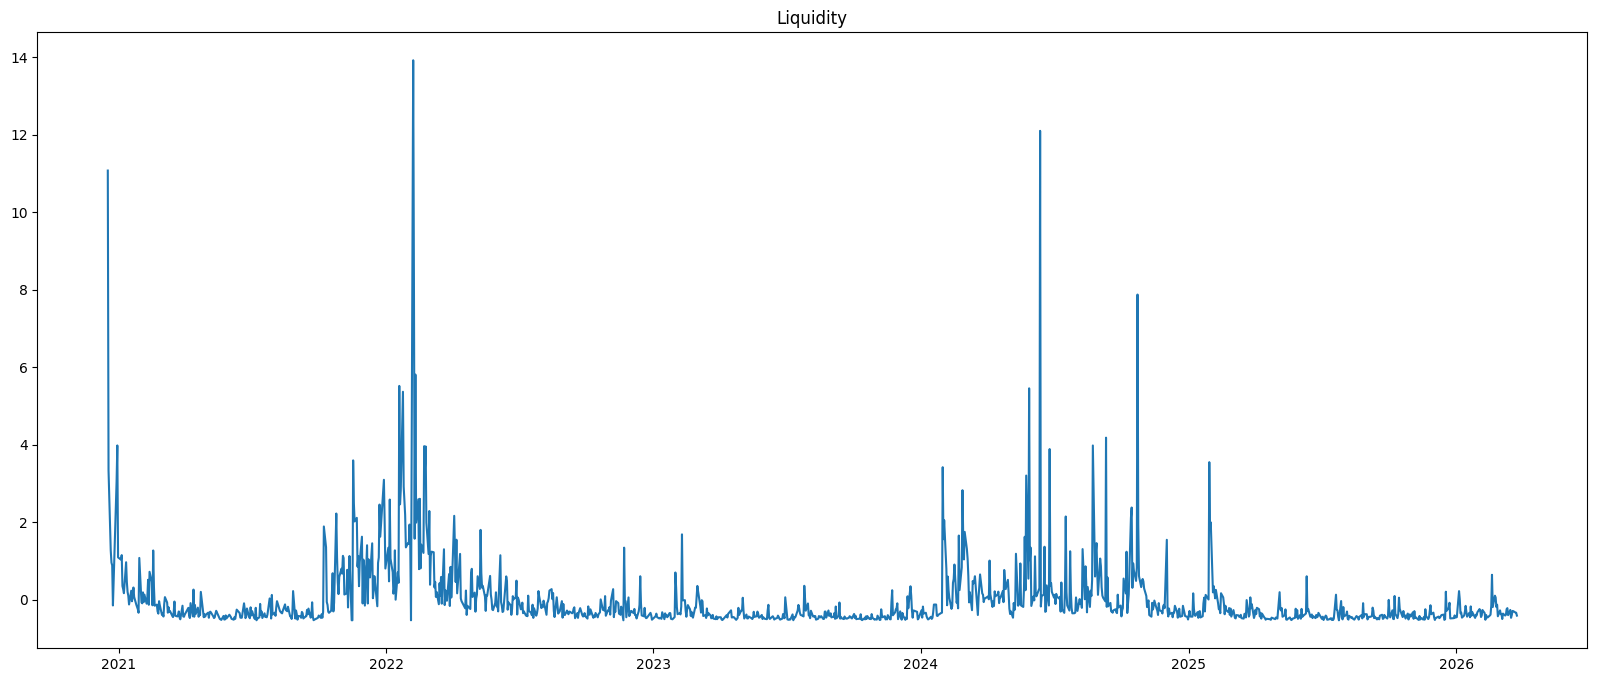

In [ ]:
# ASIDE: visualising the standardised dollar volume

plt.figure(figsize=(20, 8))

plt.plot(df.index, liquidity)
plt.title("Liquidity")